# Run Simulation — Provincial Canada

This notebook covers the full workflow end-to-end:
1. **Build the data pickle** — reads raw OECD ICIO and WIOD tables, calibrates initial conditions for all 10 provinces, and saves to `output/`.
2. **Run the simulation** — loads the pickle and steps the ABM forward with TFP and technical-coefficient growth enabled.
3. **Plot results** — produces per-province GDP and industry production charts.

## What this model does

The model simulates a multi-sector economy in which firms, households, banks, and a government interact over timesteps of **4 months each** (3 timesteps per year). Each province is treated as a separate economy with its own firms (one per industry sector), households, and government, all calibrated from a provincial input-output table for 2014. There are 43 industry sectors drawn from the OECD ICIO classification.

**Productivity growth is enabled.** Firms invest a fraction of their available cash into two kinds of improvement each timestep:
- **TFP growth** (`SimpleTFPGrowth`): raises total factor productivity so each unit of input produces more output over time.
- **Technical coefficient growth** (`SimpleTechnicalGrowth`): gradually reduces the input requirements per unit of output.

## Directory structure

```
Repo/
├── macroabm-ca/
│   └── raw_data/                   ← INPUT_PATH (raw OECD ICIO, WIOD, HFCS files)
│
└── macroabm-ca/                  ← this repo
    ├── output/                     ← created automatically
    │   ├── data_provincial.pkl     ← PKL_PATH (written by Section 4, read by Section 5)
    │   ├── results_provinces_wTFP.h5
    │   └── *.png
    ├── macro_data/
    ├── macromodel/
    └── Sample_macroabm-Canada_provincial_run.ipynb
```

## How to run

Run the cells **top to bottom, in order**. Section 4 (Create data pickle) takes several minutes and only needs to run once — it is skipped automatically if the pickle already exists.

## 1 — Autoreload

In [1]:
%load_ext autoreload
%autoreload all

## 2 — Paths

- `INPUT_PATH` — point it to raw data directory folder, containing the OECD ICIO tables, WIOD socioeconomic accounts, HFCS survey files, and other required inputs.
- `PKL_PATH` — where the calibrated `DataWrapper` pickle is saved (`output/data_provincial.pkl`). The `output/` directory is created automatically.
- `OUTPUT_FILENAME` — name of the HDF5 results file written at the end of the simulation.

In [ ]:
from pathlib import Path
# give the path to the raw data directory 
INPUT_PATH       = Path(r"Place your path to raw data here") / "raw_data"
BASE_DIR         = Path.cwd()
OUTPUT_DIRECTORY = BASE_DIR / "output"
OUTPUT_FILENAME  = "results_provinces_wTFP.h5"
PKL_PATH         = OUTPUT_DIRECTORY / "data_provincial_model.pkl"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Input path : {INPUT_PATH}  exists={INPUT_PATH.exists()}")
print(f"Pickle     : {PKL_PATH}")
print(f"Output     : {OUTPUT_DIRECTORY / OUTPUT_FILENAME}")

Input path : C:\Users\reeti\Documents\UVic\macro-main-1\raw_data  exists=True
Pickle     : c:\Users\reeti\Documents\UVic\macroabm-ca-1\output\data_provincial_model.pkl
Output     : c:\Users\reeti\Documents\UVic\macroabm-ca-1\output\results_provinces_wTFP.h5


## 3 — Imports

In [3]:
import macro_data
from macro_data import DataWrapper, configuration_utils
from macro_data.configuration.countries import Country as CountryCode
from macro_data.configuration.region import Region
from macromodel.configurations import SimulationConfiguration, CountryConfiguration
from macromodel.simulation import Simulation

## 3 — Data configuration

This section builds the `DataConfiguration` object that tells the model how to read and structure the raw input data for the 10 Canadian provinces.

**Key settings:**

| Setting | Value | Meaning |
|---------|-------|---------|
| `can_disaggregation` | `True` | Use the disaggregated Canadian industry reader (finer sector detail) |
| `aggregation_structure` | `{CAN: [10 provinces]}` | Replace the single Canada entry with 10 separate provincial economies |
| `scale` | `1000` | Monetary units are in millions CAD (divided by 1000 for model units) |
| `proxy_country_dict` | `{"CAN": "FRA"}` | Use France as the EU proxy for household finance survey data |

Each province inherits the same base configuration as the national CAN entry (one firm and one bank per industry sector, one government entity).

**Note on `can_disaggregation = True` vs `use_disagg_can_2014_reader`:** The script passed to `default_data_configuration` does not set `use_disagg_can_2014_reader=True` — instead `can_disaggregation = True` is set directly on the config object afterward. These activate the same underlying reader but via different entry points.

In [4]:
data_config = configuration_utils.default_data_configuration(
    countries=["CAN"],
    aggregate_industries=False,
    proxy_country_dict={"CAN": "FRA"},
)

data_config.year                 = 2014
data_config.time_unit            = 3
data_config.can_disaggregation   = True
data_config.aggregate_industries = False
data_config.prune_date           = None
data_config.seed                 = 0

base_config = data_config.country_configs[CountryCode("CAN")]
base_config.single_firm_per_industry  = True
base_config.single_bank               = True
base_config.single_government_entity  = True
base_config.firms_configuration.constructor = "Default"
base_config.scale = 1000

provinces = [
    Region.from_code("CAN_AB", "Alberta"),
    Region.from_code("CAN_BC", "British Columbia"),
    Region.from_code("CAN_MB", "Manitoba"),
    Region.from_code("CAN_NB", "New Brunswick"),
    Region.from_code("CAN_NL", "Newfoundland and Labrador"),
    Region.from_code("CAN_NS", "Nova Scotia"),
    Region.from_code("CAN_ON", "Ontario"),
    Region.from_code("CAN_PE", "Prince Edward Island"),
    Region.from_code("CAN_QC", "Quebec"),
    Region.from_code("CAN_SK", "Saskatchewan"),
]

for province in provinces:
    data_config.country_configs[province] = base_config
    data_config.country_configs[province].eu_proxy_country = CountryCode("FRA")

data_config.aggregation_structure = {CountryCode("CAN"): provinces}

print(f"Provinces       : {[str(p) for p in provinces]}")
print(f"Config entries  : {len(data_config.country_configs)}")

Provinces       : ['CAN_AB', 'CAN_BC', 'CAN_MB', 'CAN_NB', 'CAN_NL', 'CAN_NS', 'CAN_ON', 'CAN_PE', 'CAN_QC', 'CAN_SK']
Config entries  : 11


## 4 — Create data pickle

**Only needs to run once.** Reads all raw data files, calibrates initial conditions, and saves to `dev/pkl_files/data_provincial.pkl`.

`DataWrapper.from_config` performs these steps:
1. Reads the provincial IO table and WIOD socioeconomic accounts
2. Matches investment matrices to value-added data (handles sparse provincial sectors)
3. Constructs household wealth distributions from HFCS survey microdata
4. Builds firm-level initial conditions (wages, capital stocks, inventories)

`creator.save(PKL_PATH)` serialises the result. Once this file exists, **skip this cell** on subsequent runs and proceed directly to Section 5.

In [5]:
import time

if PKL_PATH.exists():
    print(f"Pickle already exists at {PKL_PATH} — skipping data creation.")
else:
    t0 = time.time()
    creator = DataWrapper.from_config(
        configuration=data_config,
        raw_data_path=INPUT_PATH,
        single_hfcs_survey=True,
    )
    creator.save(PKL_PATH)
    print(f"Pickle saved to {PKL_PATH}  ({(time.time() - t0) / 60:.1f} min)")

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macro_data\readers\population_data\hfcs_reader.py:332: DtypeWarning: Columns (123) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="unicode_escape").astype(object)
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macro_data\readers\population_data\hfcs_reader.py:342: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monetary_values = df.loc[:, var_numerical_union].replace(["A", "M"], np.nan).apply(
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macro_data\readers\population_data\hfcs_reader.py:332: DtypeWarning: Columns (590,592,594,614,616,626,628,916) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="unicode

Pickle saved to c:\Users\reeti\Documents\UVic\macroabm-ca-1\output\data_provincial_model.pkl  (2.1 min)


## 5 — Load data

Loads the `DataWrapper` saved in Section 4. `DataWrapper.init_from_pickle` is the correct loader when the pickle was written with `creator.save()` (which serialises a dict). If you have a pickle written with `pkl.dump(data_wrapper, f)`, use `pkl.load(f)` instead.

In [6]:
data = DataWrapper.init_from_pickle(PKL_PATH)

n_industries = data.n_industries
industries   = data.industries
print(f"n_industries : {n_industries}")
print(f"industries   : {list(industries)}")

n_industries : 43
industries   : ['A', 'B05a', 'B05b', 'B05c', 'B07', 'B09', 'C10T12', 'C13T15', 'C16', 'C17', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24a', 'C24b', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31T33', 'D', 'E', 'F', 'G', 'H49', 'H50', 'H51', 'H52', 'H53', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R_S']


## 6 — Simulation parameters

Each timestep represents **4 months** (3 timesteps = 1 year).

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `TIMESTEPS` | 10 | Number of 4-month timesteps to simulate (~3.3 years) |
| `SEED` | 1 | Random seed for reproducibility |
| `tfp_base_growth_rate` | 0.001 | Autonomous TFP growth per 4-month timestep (0.1%), independent of investment |
| `tfp_investment_elasticity` | 0.5 | How strongly TFP responds to investment spending |
| `productivity_growth_investment_effectiveness` | 0.3 | Fraction of TFP investment that actually improves productivity |
| `technical_coefficients_investment_effectiveness` | 0.3 | Fraction of technical investment that reduces input coefficients |
| `diminishing_returns_factor` | 0.1 | Rate at which returns to technical investment diminish |
| `hurdle_rate` | 0.01 | Minimum expected return required before a firm invests in productivity |
| `tfp_investment_share` | 0.5 | Share of productivity budget going to TFP (vs. technical coefficients) |
| `max_investment_fraction` | 0.2 | Maximum share of a firm's cash that can be spent on productivity investment |

In [13]:
import random

TIMESTEPS = 16
SEED      = 0

### TFP / investment parameters
tfp_base_growth_rate              = 0.001
tfp_investment_elasticity         = 0.5
productivity_growth_investment_effectiveness          = 0.3
technical_coefficients_investment_effectiveness       = 0.3
diminishing_returns_factor                            = 0.1
hurdle_rate                                           = 0.01
investment_effectiveness                              = 0.3
technical_investment_effectiveness                    = 0.3
technical_diminishing_returns                         = 0.1
tfp_investment_share                                  = 0.5
max_investment_fraction                               = 0.2

print(f"Timesteps : {TIMESTEPS}")
print(f"Seed      : {SEED}")

Timesteps : 16
Seed      : 0


## 7 — Build simulation configuration

A `SimulationConfiguration` specifies how agents behave — it is separate from the calibrated data (`DataWrapper`). This lets you change the model's rules (e.g. pricing behaviour, growth mechanisms) without reprocessing raw data.

Each province gets a `CountryConfiguration` built with `n_industry_default`, which sets up one representative firm per industry sector. The `for` loop then attaches the productivity investment configuration to each province's firms block.

**Key design choices in this notebook:**
- No energy substitution bundles — firms use the standard Leontief production function.
- Productivity investment is active for all provinces with the parameters from Section 6.

In [14]:
provinces = [
    Region.from_code("CAN_AB", "Alberta"),
    Region.from_code("CAN_BC", "British Columbia"),
    Region.from_code("CAN_MB", "Manitoba"),
    Region.from_code("CAN_NB", "New Brunswick"),
    Region.from_code("CAN_NL", "Newfoundland and Labrador"),
    Region.from_code("CAN_NS", "Nova Scotia"),
    Region.from_code("CAN_ON", "Ontario"),
    Region.from_code("CAN_PE", "Prince Edward Island"),
    Region.from_code("CAN_QC", "Quebec"),
    Region.from_code("CAN_SK", "Saskatchewan"),
]

config = SimulationConfiguration(
    seed=SEED,
    country_configurations={
        province: CountryConfiguration.n_industry_default(n_industries=n_industries)
        for province in provinces
    },
    t_max=TIMESTEPS,
)

for province in provinces:
    firms = config.country_configurations[province].firms

    firms.functions.productivity_investment_planner.name = "SimpleProductivityInvestmentPlanner"
    firms.functions.productivity_investment_planner.parameters.update({
        "n_firms":                      n_industries,
        "tfp_investment_share":          tfp_investment_share,
        "max_investment_fraction":       max_investment_fraction,
        "investment_effectiveness":      investment_effectiveness,
        "technical_investment_effectiveness": technical_investment_effectiveness,
        "technical_diminishing_returns": technical_diminishing_returns,
        "hurdle_rate":                   hurdle_rate,
    })

    firms.functions.productivity_growth.name = "SimpleTFPGrowth"
    firms.functions.productivity_growth.parameters = {
        "investment_effectiveness": productivity_growth_investment_effectiveness,
    }
    firms.parameters.tfp_base_growth_rate     = tfp_base_growth_rate
    firms.parameters.tfp_investment_elasticity = tfp_investment_elasticity

    firms.functions.technical_coefficients_growth.name = "SimpleTechnicalGrowth"
    firms.functions.technical_coefficients_growth.parameters = {
        "investment_effectiveness":  technical_coefficients_investment_effectiveness,
        "diminishing_returns_factor": diminishing_returns_factor,
    }

print("Configuration built.")

Configuration built.


## 8 — Run and save

`Simulation.from_datawrapper` combines the calibrated initial conditions (`DataWrapper`) with the behavioural rules (`SimulationConfiguration`) to create a ready-to-run simulation object.

`model.run()` steps through all `TIMESTEPS` 4-month periods. Each period the model clears labour, credit, and goods markets for all provinces in sequence.

`model.save()` writes the full time series to HDF5. The file can be large (hundreds of MB for many timesteps); subsequent sections load only what is needed for plotting.

In [15]:
import time

model = Simulation.from_datawrapper(datawrapper=data, simulation_configuration=config)

t0 = time.time()
model.run()
print(f"Simulation complete in {(time.time() - t0) / 60:.1f} min")

model.save(save_dir=OUTPUT_DIRECTORY, file_name=OUTPUT_FILENAME)
print(f"Results saved to {OUTPUT_DIRECTORY / OUTPUT_FILENAME}")

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

Simulation complete in 0.7 min
Results saved to c:\Users\reeti\Documents\UVic\macroabm-ca-1\output\results_provinces_wTFP.h5


## 9 — Results utilities

Helper functions for loading and inspecting the HDF5 output file. The HDF5 file is organised as a hierarchy: `<province>/<agent_type>/<variable>` (e.g. `CAN_ON/firms/production`). The utilities below let you:

- **`get_tree`** — build a dictionary representation of the file structure.
- **`list_dataset_paths`** — list every dataset path in the file.
- **`load_dataset`** — load a specific dataset as a NumPy array.
- **`compute_real_gdp`** — compute real GDP by deflating nominal GDP with the CPI.
- **`get_column_labels`** — map industry indices to human-readable names (requires `can_industries_wnames.csv`).
- **`sum_regions`** — aggregate a variable across all provinces.

Running this cell also prints the top-level structure of the results file so you can see what is available.

In [19]:
import os
from typing import Any, Dict, Iterable, List, Optional, Tuple

import h5py
import numpy as np
import pandas as pd

# Path to industry names CSV (copied from macroabm-ca/sesit_tools/)
INDUSTRY_NAMES_CSV = INPUT_PATH / "can_industries_wnames.csv"

TreeNode = Dict[str, Any]


def load_industry_mapping() -> Dict[int, str]:
    if not INDUSTRY_NAMES_CSV.exists():
        return {}
    df = pd.read_csv(INDUSTRY_NAMES_CSV)
    return dict(zip(df["Firm_ID"], df["Industry_Name"]))


def _build_tree(group: h5py.Group) -> TreeNode:
    tree: TreeNode = {}
    for key in group.keys():
        obj = group[key]
        if isinstance(obj, h5py.Dataset):
            tree[key] = {"type": "dataset"}
        else:
            tree[key] = {"type": "group", "children": _build_tree(obj)}
    return tree


def get_tree(file_path) -> TreeNode:
    with h5py.File(file_path, "r") as f:
        return _build_tree(f)


def list_dataset_paths(tree: TreeNode, prefix: str = "") -> List[str]:
    paths: List[str] = []
    for key in sorted(tree.keys()):
        entry = tree[key]
        current_path = f"{prefix}/{key}" if prefix else key
        if entry["type"] == "dataset":
            paths.append(current_path)
        else:
            paths.extend(list_dataset_paths(entry["children"], current_path))
    return paths


def load_dataset(file_path, dataset_path: str) -> np.ndarray:
    with h5py.File(file_path, "r") as f:
        return f[dataset_path][()]


def compute_real_gdp(file_path, dataset_path: str) -> Optional[np.ndarray]:
    parent = "/".join(dataset_path.split("/")[:-1])
    gdp_path  = f"{parent}/gdp_output" if parent else "gdp_output"
    cpi_path  = f"{parent}/cpi"        if parent else "cpi"
    with h5py.File(file_path, "r") as f:
        if gdp_path not in f or cpi_path not in f:
            return None
        gdp = f[gdp_path][()].astype(float)
        cpi = f[cpi_path][()].astype(float)
    return np.divide(gdp, cpi, out=np.full_like(gdp, np.nan), where=cpi != 0)


def get_column_labels(
    file_path, dataset_path: str, industry_mapping: Optional[Dict[int, str]] = None
) -> Optional[List[str]]:
    columns_path = f"{dataset_path}_columns"
    with h5py.File(file_path, "r") as f:
        if columns_path not in f:
            return None
        cols = np.asarray(f[columns_path][()])
    if cols.ndim == 1:
        if industry_mapping:
            return [industry_mapping.get(int(i), str(int(i))) for i in cols]
        return [str(int(i)) for i in cols]
    if cols.ndim == 2 and cols.shape[1] == 2:
        if industry_mapping:
            return [f"[{industry_mapping.get(int(a), str(int(a)))}, {industry_mapping.get(int(b), str(int(b)))}]"
                    for a, b in cols]
        return [f"[{int(a)}, {int(b)}]" for a, b in cols]
    return [str(x) for x in cols.flatten()]


def merge_trees(trees: Iterable[TreeNode]) -> TreeNode:
    merged: TreeNode = {}
    for tree in trees:
        for key, entry in tree.items():
            if key not in merged:
                merged[key] = entry
                continue
            if merged[key]["type"] == "group" or entry["type"] == "group":
                merged[key] = {
                    "type": "group",
                    "children": merge_trees([
                        merged[key].get("children", {}),
                        entry.get("children", {}),
                    ]),
                }
    return merged


def add_can_region(tree: TreeNode) -> List[str]:
    regions = [k for k, v in tree.items() if v["type"] == "group" and k != "CAN" and "CAN" in k]
    if regions:
        can_children = merge_trees([tree[r]["children"] for r in regions])
        tree["CAN"] = {"type": "group", "children": can_children}
    return regions


def sum_regions(file_path, regions: List[str], tail_path: str) -> Optional[np.ndarray]:
    total: Optional[np.ndarray] = None
    with h5py.File(file_path, "r") as f:
        for region in regions:
            full = f"{region}/{tail_path}"
            if full not in f:
                continue
            data = f[full][()].astype(float)
            total = data.copy() if total is None else total + data
    return total


# Load industry mapping once
industry_mapping = load_industry_mapping()
print(f"Industry mapping loaded: {len(industry_mapping)} industries")

# Inspect H5 structure
tree = get_tree(OUTPUT_DIRECTORY / OUTPUT_FILENAME)
regions = add_can_region(tree)
all_paths = list_dataset_paths(tree)

print(f"\nProvinces found : {regions}")
print(f"Total datasets  : {len(all_paths)}")
print("\nTop-level keys:")
for k, v in sorted(tree.items()):
    print(f"  {k}  [{v['type']}]")

Industry mapping loaded: 50 industries

Provinces found : ['CAN_AB', 'CAN_BC', 'CAN_MB', 'CAN_NB', 'CAN_NL', 'CAN_NS', 'CAN_ON', 'CAN_PE', 'CAN_QC', 'CAN_SK']
Total datasets  : 8494

Top-level keys:
  CAN  [group]
  CAN_AB  [group]
  CAN_BC  [group]
  CAN_MB  [group]
  CAN_NB  [group]
  CAN_NL  [group]
  CAN_NS  [group]
  CAN_ON  [group]
  CAN_PE  [group]
  CAN_QC  [group]
  CAN_SK  [group]
  GM  [group]
  ROW  [group]


## 10 — Plot results

Three standard plots are produced and saved to `output/`:
1. **Nominal GDP by province** — raw GDP output each 4-month timestep.
2. **Real GDP by province** — nominal GDP deflated by the CPI (base 2014).
3. **Production by industry** — total production summed across all provinces, showing the top 10 industries by average output.

PNG files are written to `output/` alongside the HDF5 file.

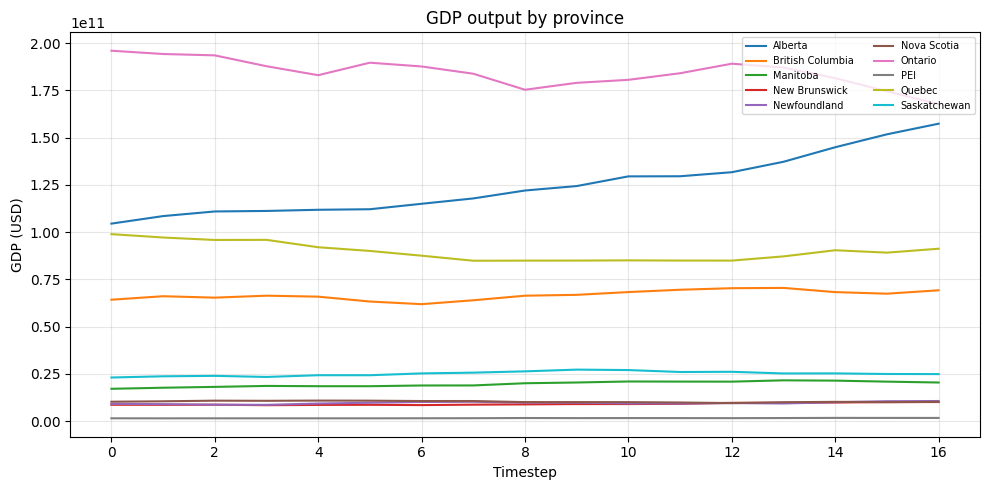

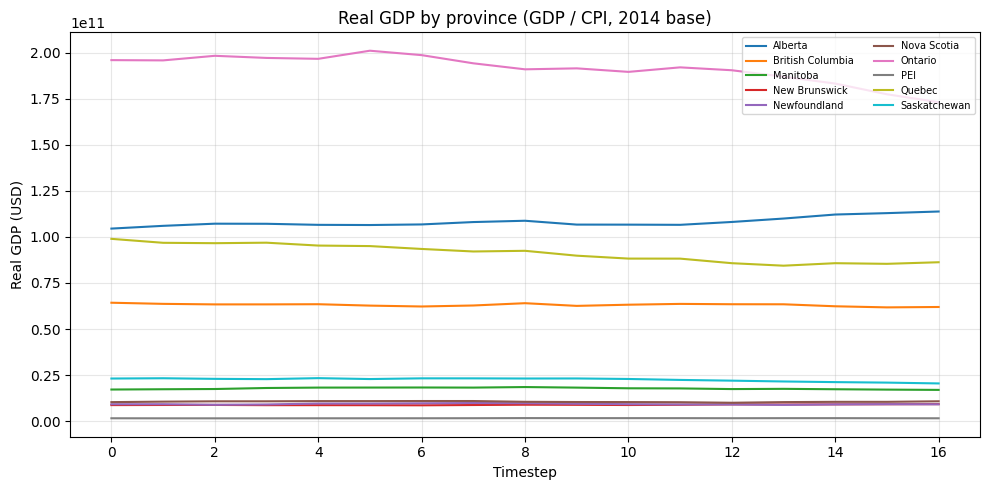

In [20]:
import matplotlib.pyplot as plt

H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
PROVINCE_LABELS = {
    "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}


# ── GDP by province ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
with h5py.File(H5_FILE, "r") as f:
    for region in regions:
        path = f"{region}/economy/gdp_output"
        if path in f:
            gdp = f[path][()].astype(float)
            ax.plot(gdp, label=PROVINCE_LABELS.get(region, region))
ax.set_title("GDP output by province")
ax.set_xlabel("Timestep")
ax.set_ylabel("GDP (USD)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "gdp_by_province.png", dpi=120)
plt.show()


# ── Real GDP by province (GDP / CPI) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for region in regions:
    real_gdp = compute_real_gdp(H5_FILE, f"{region}/economy/real_gdp_2014")
    if real_gdp is not None:
        ax.plot(real_gdp, label=PROVINCE_LABELS.get(region, region))
ax.set_title("Real GDP by province (GDP / CPI, 2014 base)")
ax.set_xlabel("Timestep")
ax.set_ylabel("Real GDP (USD)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "real_gdp_by_province.png", dpi=120)
plt.show()

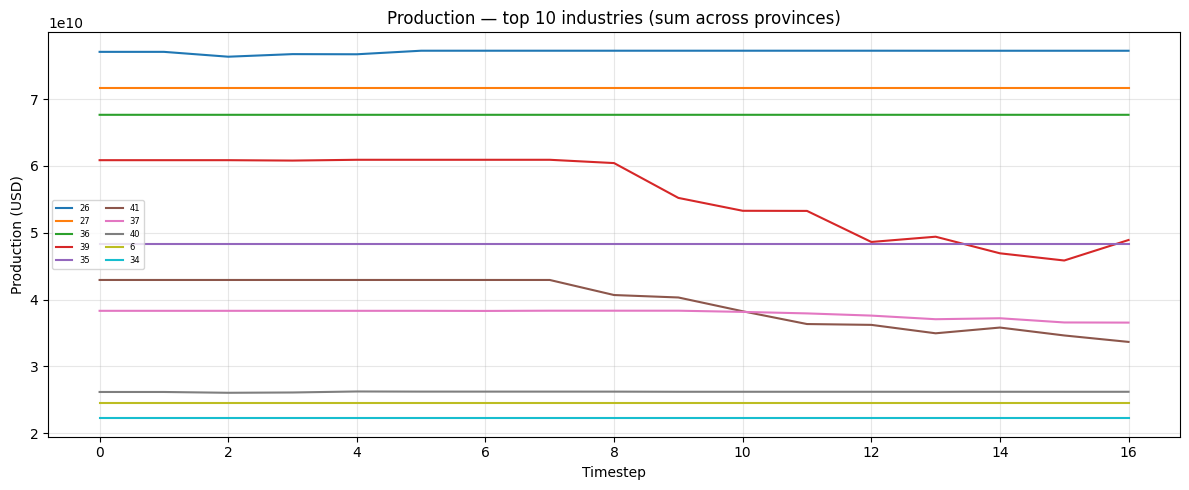

All dataset paths in H5 file:
  CAN/CM/total_newly_loans_granted_firms_long_term
  CAN/CM/total_newly_loans_granted_firms_short_term
  CAN/CM/total_newly_loans_granted_households_consumption
  CAN/CM/total_newly_loans_granted_mortgages
  CAN/CM/total_outstanding_loans_granted_firms_long_term
  CAN/CM/total_outstanding_loans_granted_firms_short_term
  CAN/CM/total_outstanding_loans_granted_households_consumption
  CAN/CM/total_outstanding_loans_granted_mortgages
  CAN/banks/average_interest_rate_on_firm_deposits
  CAN/banks/average_interest_rate_on_household_deposits
  CAN/banks/average_interest_rates_on_household_consumption_loans
  CAN/banks/average_interest_rates_on_long_term_firm_loans
  CAN/banks/average_interest_rates_on_mortgages
  CAN/banks/average_interest_rates_on_short_term_firm_loans
  CAN/banks/average_overdraft_rate_on_firm_deposits
  CAN/banks/average_overdraft_rate_on_household_deposits
  CAN/banks/consumption_loans_to_households
  CAN/banks/deposits
  CAN/banks/deposits

In [21]:
# ── Production by industry (summed across provinces) ────────────────────────
production_total = sum_regions(H5_FILE, regions, "firms/production")

if production_total is not None:
    labels = get_column_labels(H5_FILE, f"{regions[0]}/firms/production", industry_mapping)
    n_show = min(10, production_total.shape[1])   # top-10 industries by mean production
    mean_prod = production_total.mean(axis=0)
    top_idx = np.argsort(mean_prod)[::-1][:n_show]

    fig, ax = plt.subplots(figsize=(12, 5))
    for i in top_idx:
        name = labels[i] if labels else str(i)
        ax.plot(production_total[:, i], label=name)
    ax.set_title(f"Production — top {n_show} industries (sum across provinces)")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Production (USD)")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRECTORY / "production_top_industries.png", dpi=120)
    plt.show()


# ── Explore available datasets ───────────────────────────────────────────────
print("All dataset paths in H5 file:")
for p in all_paths:
    print(f"  {p}")